# Chess Elo Prediction with Neural Networks

Predict White and Black Elo ratings from move sequences and game-level features
using a Bidirectional LSTM with attention. Trained on ~100k Lichess games.
Multi-task setup: one shared backbone, two prediction heads.

In [32]:
import io, re, os, time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zstandard as zstd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, median_absolute_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import stats
from joblib import Parallel, delayed

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import chess_features_final as cff

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

# --- config ---
DATA_PATH       = "../../data/elias_data/lichess_db_standard_rated_2017-05.pgn.zst"
MAX_GAMES       = 10000 # was 100_000
RANDOM_STATE    = 42
BATCH_SIZE      = 128
EMBED_DIM       = 64
HIDDEN_DIM      = 128
NUM_EPOCHS      = 15
LR              = 1e-3
DROPOUT         = 0.3
MIN_PLIES       = 12
MAX_SEQ_LEN     = 120
VAL_FRAC        = 0.10
TEST_FRAC       = 0.10
ELO_BINS        = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]
EXCLUDE_TERMS   = {"Time forfeit", "Abandoned", "Unterminated"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Config: {MAX_GAMES} games, embed={EMBED_DIM}, hidden={HIDDEN_DIM}, "
      f"lr={LR}, dropout={DROPOUT}, epochs={NUM_EPOCHS}")

Device: cpu
Config: 10000 games, embed=64, hidden=128, lr=0.001, dropout=0.3, epochs=15


In [33]:
def load_pgn_zst(path, max_games):
    """Stream-read a .pgn.zst file and parse headers + move text."""
    records = []
    with open(path, 'rb') as fh:
        dctx = zstd.ZstdDecompressor()
        reader = dctx.stream_reader(fh)
        text_stream = io.TextIOWrapper(reader, encoding='utf-8', errors='replace')

        headers = {}
        moves_lines = []
        in_moves = False

        for line in text_stream:
            line = line.strip()

            if line.startswith('['):
                in_moves = False
                # parse header tag
                m = re.match(r'\[(\w+)\s+"(.*)"\]', line)
                if m:
                    headers[m.group(1)] = m.group(2)
            elif line == '':
                if headers and moves_lines:
                    # end of game
                    headers['Moves'] = ' '.join(moves_lines)
                    records.append(headers)
                    headers = {}
                    moves_lines = []
                    if len(records) >= max_games:
                        break
                elif headers:
                    in_moves = True
            else:
                if in_moves or headers:
                    moves_lines.append(line)

        # last game if file doesn't end with blank line
        if headers and moves_lines and len(records) < max_games:
            headers['Moves'] = ' '.join(moves_lines)
            records.append(headers)

    df = pd.DataFrame(records)
    return df


t0 = time.time()
df_raw = load_pgn_zst(DATA_PATH, MAX_GAMES)
print(f"Loaded {len(df_raw)} games in {time.time()-t0:.1f}s")

# clean up types
for col in ['WhiteElo', 'BlackElo']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw.dropna(subset=['WhiteElo', 'BlackElo', 'Moves'], inplace=True)
df_raw['WhiteElo'] = df_raw['WhiteElo'].astype(int)
df_raw['BlackElo'] = df_raw['BlackElo'].astype(int)

# filter terminations
if 'Termination' in df_raw.columns:
    before = len(df_raw)
    df_raw = df_raw[~df_raw['Termination'].isin(EXCLUDE_TERMS)].reset_index(drop=True)
    print(f"Filtered {before - len(df_raw)} games by termination")

# parse time control
tc_pat = re.compile(r'^(\d+)\+(\d+)')
def parse_tc(tc_str):
    m = tc_pat.match(str(tc_str))
    if m:
        return int(m.group(1)), int(m.group(2))
    return np.nan, np.nan

df_raw[['tc_base', 'tc_inc']] = df_raw['TimeControl'].apply(
    lambda x: pd.Series(parse_tc(x)))
df_raw.dropna(subset=['tc_base'], inplace=True)
df_raw['tc_base'] = df_raw['tc_base'].astype(int)
df_raw['tc_inc'] = df_raw['tc_inc'].astype(int)

print(f"After filters: {len(df_raw)} games")
print(f"Elo range: White {df_raw.WhiteElo.min()}-{df_raw.WhiteElo.max()}, "
      f"Black {df_raw.BlackElo.min()}-{df_raw.BlackElo.max()}")

Loaded 10000 games in 0.3s
Filtered 3280 games by termination
After filters: 6685 games
Elo range: White 803-2692, Black 799-2691


In [34]:
print("Extracting board features...")
t0 = time.time()
board_feats = cff.extract_features_dataframe(df_raw, n_jobs=-1)
print(f"Board features done in {time.time()-t0:.1f}s — {board_feats.shape[1]} columns")

# --- clock features ---
_CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+(?:\.\d+)?)\]')

def _extract_clocks(pgn_str):
    """Pull all clock values in seconds from move text."""
    return [int(m[0])*3600 + int(m[1])*60 + float(m[2])
            for m in _CLK_RE.findall(pgn_str)]

def clock_features_row(pgn_str, tc_base):
    """Compute normalised clock stats for one game."""
    clocks = _extract_clocks(pgn_str)
    if len(clocks) < 4 or tc_base <= 0:
        return {k: np.nan for k in [
            'w_avg_time_norm', 'w_std_time_norm', 'w_max_time_norm',
            'w_time_pressure', 'w_opening_pace',
            'b_avg_time_norm', 'b_std_time_norm', 'b_max_time_norm',
            'b_time_pressure', 'b_opening_pace',
        ]}
    w_clk = clocks[0::2]  # white moves
    b_clk = clocks[1::2]  # black moves

    # time spent per move = diff between consecutive clocks
    def _diffs(c):
        return [max(0, c[i] - c[i+1]) for i in range(len(c)-1)] if len(c) > 1 else [0]

    w_spent = _diffs(w_clk)
    b_spent = _diffs(b_clk)

    def _stats(spent, remaining, tc):
        arr = np.array(spent)
        rem = np.array(remaining)
        return {
            'avg_time_norm': arr.mean() / tc,
            'std_time_norm': arr.std() / tc if len(arr) > 1 else 0,
            'max_time_norm': arr.max() / tc,
            'time_pressure': int(np.sum(rem[1:] < 30)) if len(rem) > 1 else 0,
            'opening_pace':  np.mean(spent[:5]) / tc if len(spent) >= 5 else arr.mean() / tc,
        }

    ws = _stats(w_spent, w_clk, tc_base)
    bs = _stats(b_spent, b_clk, tc_base)

    return {f'w_{k}': v for k, v in ws.items()} | {f'b_{k}': v for k, v in bs.items()}


print("Extracting clock features...")
t0 = time.time()
clock_records = Parallel(n_jobs=-1)(
    delayed(clock_features_row)(m, tc)
    for m, tc in zip(df_raw['Moves'].tolist(), df_raw['tc_base'].tolist())
)
clock_feats = pd.DataFrame(clock_records, index=df_raw.index)
print(f"Clock features done in {time.time()-t0:.1f}s — {clock_feats.shape[1]} columns")

# join everything
df = pd.concat([df_raw, board_feats, clock_feats], axis=1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"Final feature matrix: {df.shape}")

Extracting board features...
Board features done in 6.5s — 35 columns
Extracting clock features...
Clock features done in 0.6s — 10 columns
Final feature matrix: (6685, 65)


In [35]:
class Vocab:
    """Simple token vocabulary."""
    def __init__(self):
        self.move_to_id = {'<PAD>': 0, '<UNK>': 1}
        self._next = 2

    def add(self, token):
        if token not in self.move_to_id:
            self.move_to_id[token] = self._next
            self._next += 1

    def encode(self, token):
        return self.move_to_id.get(token, 1)

    def decode_map(self):
        return {v: k for k, v in self.move_to_id.items()}

    def __len__(self):
        return len(self.move_to_id)


_MOVE_RE = re.compile(
    r'(?:\d+\.+\s*)?'           # optional move number
    r'([KQRBN]?[a-h]?[1-8]?x?[a-h][1-8](?:=[QRBN])?[+#]?'
    r'|O-O-O[+#]?|O-O[+#]?)'   # castling
)
_EVAL_RE = re.compile(r'\[%eval\s+([^\]]+)\]')

def parse_pgn(pgn_str):
    """Extract SAN moves, clock times (seconds), and eval scores."""
    moves = _MOVE_RE.findall(pgn_str)
    clocks = _extract_clocks(pgn_str)
    evals = []
    for m in _EVAL_RE.findall(pgn_str):
        try:
            if '#' in m:
                evals.append(100.0 if int(m.replace('#','')) > 0 else -100.0)
            else:
                evals.append(float(m))
        except ValueError:
            evals.append(0.0)
    return moves, clocks, evals


print("Tokenizing moves...")
parsed = df['Moves'].apply(parse_pgn)
df['clean_moves']  = parsed.apply(lambda x: x[0])
df['clean_clocks'] = parsed.apply(lambda x: x[1])
df['clean_evals']  = parsed.apply(lambda x: x[2])
df['n_moves'] = df['clean_moves'].apply(len)

# filter short games
before = len(df)
df = df[df['n_moves'] >= MIN_PLIES].reset_index(drop=True)
print(f"Dropped {before - len(df)} short games (< {MIN_PLIES} plies)")

# build vocab
vocab = Vocab()
for move_list in df['clean_moves']:
    for m in move_list:
        vocab.add(m)

print(f"Vocab size: {len(vocab)} unique moves")
print(f"Dataset: {len(df)} games ready")

Tokenizing moves...
Dropped 101 short games (< 12 plies)
Vocab size: 3373 unique moves
Dataset: 6584 games ready


In [ ]:
# pick numeric feature columns, dropping targets and metadata
_exclude = {'WhiteElo', 'BlackElo', 'n_moves', 'tc_base', 'tc_inc'}
_non_numeric = {'Moves', 'Result', 'TimeControl', 'ECO', 'Termination',
                'clean_moves', 'clean_clocks', 'clean_evals',
                'castle_side_white', 'castle_side_black'}

static_cols = [c for c in df.select_dtypes(include=[np.number]).columns
               if c not in _exclude]
num_static = len(static_cols)
print(f"Static feature columns: {num_static}")

# train / val / test split
idx_train, idx_temp = train_test_split(
    df.index, test_size=VAL_FRAC + TEST_FRAC, random_state=RANDOM_STATE)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC), random_state=RANDOM_STATE)

print(f"Split: {len(idx_train)} train / {len(idx_val)} val / {len(idx_test)} test")


class ChessDataset(Dataset):
    def __init__(self, df_sub, vocab, static_cols):
        self.samples = []
        static_arr = df_sub[static_cols].fillna(0).values.astype(np.float32)

        for i, (_, row) in enumerate(df_sub.iterrows()):
            moves = row['clean_moves'][:MAX_SEQ_LEN]
            ids = [vocab.encode(m) for m in moves]
            L = len(ids)

            # normalise clocks by tc_base, fill missing with 0.5
            tc = max(1, row.get('tc_base', 180))
            raw_clk = row['clean_clocks'][:L]
            clks = [(c / tc) for c in raw_clk]
            clks += [0.5] * (L - len(clks))  # pad if fewer clocks than moves
            clks = [min(max(c, 0.0), 2.0) for c in clks]

            turns = [float(j % 2) for j in range(L)]  # 0=white, 1=black

            targets = np.array([row['WhiteElo'], row['BlackElo']], dtype=np.float32)
            self.samples.append((
                torch.tensor(ids, dtype=torch.long),
                torch.tensor(clks, dtype=torch.float32),
                torch.tensor(turns, dtype=torch.float32),
                torch.tensor(static_arr[i], dtype=torch.float32),
                torch.tensor(targets, dtype=torch.float32),
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ids, clks, turns, static, targets = self.samples[idx]
        return {'moves': ids, 'clocks': clks, 'turns': turns,
                'static': static, 'targets': targets}


def collate_fn(batch):
    moves  = [b['moves'][:MAX_SEQ_LEN]  for b in batch]
    clocks = [b['clocks'][:MAX_SEQ_LEN] for b in batch]
    turns  = [b['turns'][:MAX_SEQ_LEN]  for b in batch]

    # pad sequences
    moves_pad  = pad_sequence(moves, batch_first=True, padding_value=0)
    clocks_pad = pad_sequence(clocks, batch_first=True, padding_value=0.0)
    turns_pad  = pad_sequence(turns, batch_first=True, padding_value=0.0)

    # mask: 1 where real tokens, 0 where padding
    mask = (moves_pad != 0).float()

    static  = torch.stack([b['static'] for b in batch])
    targets = torch.stack([b['targets'] for b in batch])

    return {'moves': moves_pad, 'clocks': clocks_pad, 'turns': turns_pad,
            'mask': mask, 'static': static, 'targets': targets}


print("Building datasets...")
t0 = time.time()
train_ds = ChessDataset(df.loc[idx_train], vocab, static_cols)
val_ds   = ChessDataset(df.loc[idx_val],   vocab, static_cols)
test_ds  = ChessDataset(df.loc[idx_test],  vocab, static_cols)
print(f"Datasets built in {time.time()-t0:.1f}s")
pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, pin_memory=pin, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, pin_memory=pin, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, pin_memory=pin, num_workers=0)

Static feature columns: 43
Split: 5267 train / 658 val / 659 test
Building datasets...
Datasets built in 0.9s


In [37]:
class ChessEloPredictor(nn.Module):
    def __init__(self, vocab_size, num_static, embed_dim=64, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.move_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim + 2,  # +clock +turn
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        # attention pooling
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        # static features branch
        self.static_branch = nn.Sequential(
            nn.Linear(num_static, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        # shared trunk after merging sequence + static
        self.shared = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 32, 128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        # one head per color
        self.white_head = nn.Linear(128, 1)
        self.black_head = nn.Linear(128, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _attend(self, lstm_out, mask):
        """Attention pooling over LSTM outputs."""
        scores = self.attention(lstm_out).squeeze(-1)     # (B, L)
        scores = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=1)                # (B, L)
        context = torch.bmm(weights.unsqueeze(1), lstm_out).squeeze(1)  # (B, H*2)
        return context, weights

    def forward(self, moves, clocks, turns, mask, static_feats):
        x = self.move_embed(moves)                        # (B, L, E)
        x = torch.cat([x, clocks.unsqueeze(-1),
                        turns.unsqueeze(-1)], dim=-1)     # (B, L, E+2)
        lstm_out, _ = self.lstm(x)                        # (B, L, H*2)
        context, attn_w = self._attend(lstm_out, mask)

        static_out = self.static_branch(static_feats)     # (B, 32)
        combined = torch.cat([context, static_out], dim=1)
        shared = self.shared(combined)                     # (B, 128)

        w_pred = self.white_head(shared).squeeze(-1)
        b_pred = self.black_head(shared).squeeze(-1)
        return w_pred, b_pred, attn_w

    def get_game_vector(self, moves, clocks, turns, mask, static_feats):
        """Return the 128-d game representation (before heads) for clustering."""
        x = self.move_embed(moves)
        x = torch.cat([x, clocks.unsqueeze(-1),
                        turns.unsqueeze(-1)], dim=-1)
        lstm_out, _ = self.lstm(x)
        context, _ = self._attend(lstm_out, mask)
        static_out = self.static_branch(static_feats)
        combined = torch.cat([context, static_out], dim=1)
        return self.shared(combined)


model = ChessEloPredictor(len(vocab), num_static, EMBED_DIM, HIDDEN_DIM, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(model)

Model parameters: 870,499
ChessEloPredictor(
  (move_embed): Embedding(3373, 64, padding_idx=0)
  (lstm): LSTM(66, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (static_branch): Sequential(
    (0): Linear(in_features=43, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
  )
  (shared): Sequential(
    (0): Linear(in_features=288, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (white_head): Linear(in_features=128, out_features=1, bias=True)
  (black_head): Linear(in_features=128, out_features=1, bias=True)
)


c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  1/15 | Train: 302883.0 | Val: 265298.8 | MAE W: 1381  B: 1356 | LR: 0.001000


c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  2/15 | Train: 157652.7 | Val: 68359.1 | MAE W: 403  B: 407 | LR: 0.001000


c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 13/15 | Train: 43490.9 | Val: 35964.2 | MAE W: 228  B: 223 | LR: 0.001000


c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 14/15 | Train: 42574.3 | Val: 40313.1 | MAE W: 245  B: 245 | LR: 0.001000


c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 15/15 | Train: 42141.8 | Val: 36185.7 | MAE W: 228  B: 226 | LR: 0.001000


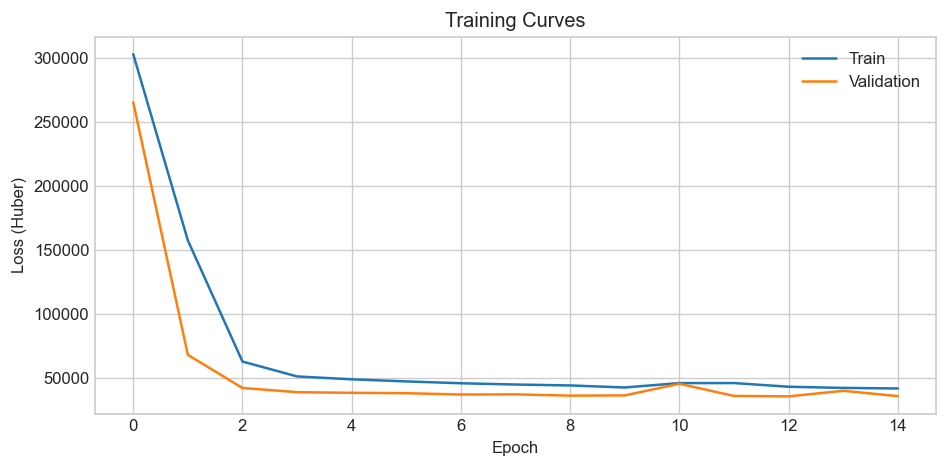

In [38]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5)
loss_fn = nn.HuberLoss(delta=100.0)

train_losses = []
val_losses = []
best_val = float('inf')
patience_ctr = 0
PATIENCE = 3

for epoch in range(NUM_EPOCHS):
    # --- train ---
    model.train()
    running = 0.0
    n_batches = 0
    for batch in train_loader:
        mv   = batch['moves'].to(device)
        cl   = batch['clocks'].to(device)
        tu   = batch['turns'].to(device)
        mask = batch['mask'].to(device)
        st   = batch['static'].to(device)
        tgt  = batch['targets'].to(device)

        w_pred, b_pred, _ = model(mv, cl, tu, mask, st)
        loss = loss_fn(w_pred, tgt[:, 0]) + loss_fn(b_pred, tgt[:, 1])

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running += loss.item()
        n_batches += 1

    train_loss = running / max(n_batches, 1)
    train_losses.append(train_loss)

    # --- validate ---
    model.eval()
    val_running = 0.0
    val_n = 0
    all_w_pred, all_b_pred, all_w_true, all_b_true = [], [], [], []

    with torch.no_grad():
        for batch in val_loader:
            mv   = batch['moves'].to(device)
            cl   = batch['clocks'].to(device)
            tu   = batch['turns'].to(device)
            mask = batch['mask'].to(device)
            st   = batch['static'].to(device)
            tgt  = batch['targets'].to(device)

            w_pred, b_pred, _ = model(mv, cl, tu, mask, st)
            loss = loss_fn(w_pred, tgt[:, 0]) + loss_fn(b_pred, tgt[:, 1])
            val_running += loss.item()
            val_n += 1

            all_w_pred.extend(w_pred.cpu().numpy())
            all_b_pred.extend(b_pred.cpu().numpy())
            all_w_true.extend(tgt[:, 0].cpu().numpy())
            all_b_true.extend(tgt[:, 1].cpu().numpy())

    val_loss = val_running / max(val_n, 1)
    val_losses.append(val_loss)
    w_mae = mean_absolute_error(all_w_true, all_w_pred)
    b_mae = mean_absolute_error(all_b_true, all_b_pred)
    cur_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train: {train_loss:7.1f} | Val: {val_loss:7.1f} | "
          f"MAE W: {w_mae:.0f}  B: {b_mae:.0f} | LR: {cur_lr:.6f}")

    scheduler.step(val_loss)

    # early stopping
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), 'best_chess_model.pth')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# plot training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (Huber)')
ax.set_title('Training Curves')
ax.legend()
plt.tight_layout()
plt.show()

## Evaluation

In [39]:
model.load_state_dict(torch.load('best_chess_model.pth', map_location=device))
model.eval()

test_w_pred, test_b_pred = [], []
test_w_true, test_b_true = [], []

with torch.no_grad():
    for batch in test_loader:
        mv   = batch['moves'].to(device)
        cl   = batch['clocks'].to(device)
        tu   = batch['turns'].to(device)
        mask = batch['mask'].to(device)
        st   = batch['static'].to(device)
        tgt  = batch['targets'].to(device)

        w_pred, b_pred, _ = model(mv, cl, tu, mask, st)
        test_w_pred.extend(w_pred.cpu().numpy())
        test_b_pred.extend(b_pred.cpu().numpy())
        test_w_true.extend(tgt[:, 0].cpu().numpy())
        test_b_true.extend(tgt[:, 1].cpu().numpy())

test_w_pred = np.array(test_w_pred)
test_b_pred = np.array(test_b_pred)
test_w_true = np.array(test_w_true)
test_b_true = np.array(test_b_true)

w_mae = mean_absolute_error(test_w_true, test_w_pred)
b_mae = mean_absolute_error(test_b_true, test_b_pred)
combined_mae = (w_mae + b_mae) / 2

w_med = median_absolute_error(test_w_true, test_w_pred)
b_med = median_absolute_error(test_b_true, test_b_pred)

# percentage within thresholds
all_errors = np.concatenate([np.abs(test_w_pred - test_w_true),
                             np.abs(test_b_pred - test_b_true)])
within_100 = np.mean(all_errors < 100) * 100
within_200 = np.mean(all_errors < 200) * 100

print(f"Test MAE  — White: {w_mae:.1f}  Black: {b_mae:.1f}  Combined: {combined_mae:.1f}")
print(f"Median AE — White: {w_med:.1f}  Black: {b_med:.1f}")
print(f"Within 100 Elo: {within_100:.1f}%")
print(f"Within 200 Elo: {within_200:.1f}%")

c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test MAE  — White: 217.2  Black: 225.7  Combined: 221.4
Median AE — White: 191.2  Black: 195.7
Within 100 Elo: 28.2%
Within 200 Elo: 51.7%


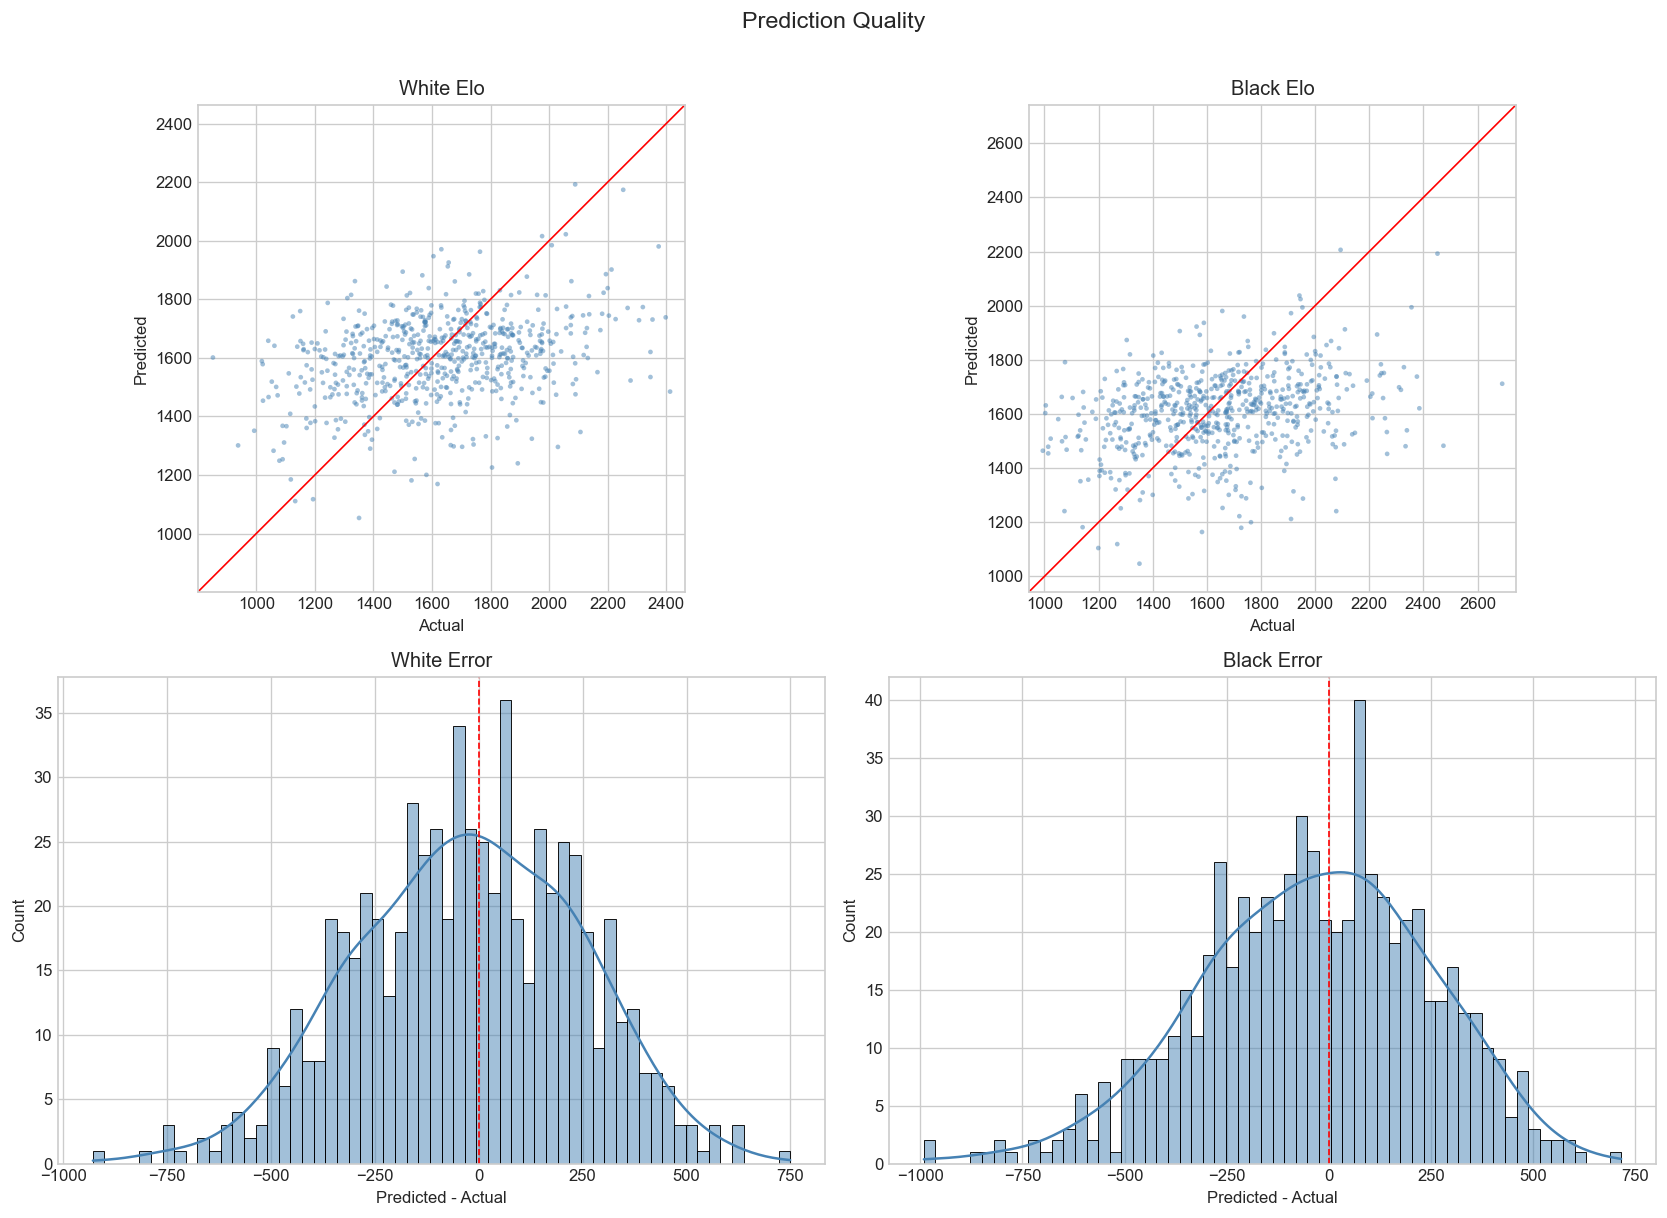

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# scatter: pred vs actual
for ax, preds, trues, label in [
    (axes[0, 0], test_w_pred, test_w_true, 'White Elo'),
    (axes[0, 1], test_b_pred, test_b_true, 'Black Elo'),
]:
    ax.scatter(trues, preds, alpha=0.5, s=8, c='steelblue', edgecolors='none')
    lo = min(trues.min(), preds.min()) - 50
    hi = max(trues.max(), preds.max()) + 50
    ax.plot([lo, hi], [lo, hi], 'r-', lw=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(label)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal')

# error histograms
for ax, preds, trues, label in [
    (axes[1, 0], test_w_pred, test_w_true, 'White Error'),
    (axes[1, 1], test_b_pred, test_b_true, 'Black Error'),
]:
    errors = preds - trues
    sns.histplot(errors, bins=60, kde=True, ax=ax, color='steelblue')
    ax.axvline(0, color='red', lw=1, ls='--')
    ax.set_xlabel('Predicted - Actual')
    ax.set_title(label)

fig.suptitle('Prediction Quality', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


MAE by Elo bracket:
-----------------------------------
           (0, 1000]  MAE=  485  (n=4)
        (1000, 1200]  MAE=  386  (n=71)
        (1200, 1400]  MAE=  250  (n=211)
        (1400, 1600]  MAE=  138  (n=324)
        (1600, 1800]  MAE=  127  (n=343)
        (1800, 2000]  MAE=  266  (n=241)
        (2000, 2200]  MAE=  404  (n=87)
        (2200, 2500]  MAE=  587  (n=36)
        (2500, 4000]  MAE=  979  (n=1)


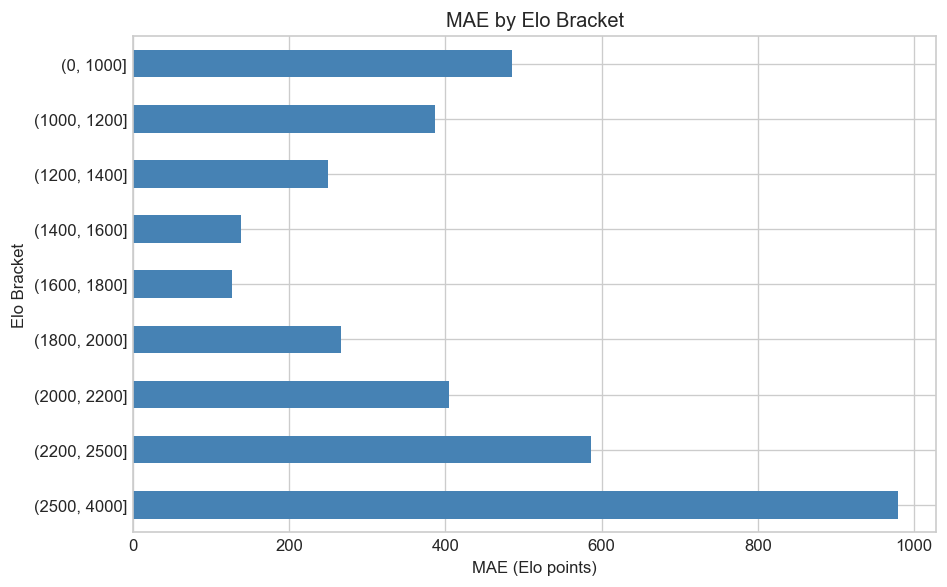

In [41]:
all_true = np.concatenate([test_w_true, test_b_true])
all_pred = np.concatenate([test_w_pred, test_b_pred])

bin_labels = pd.cut(all_true, bins=ELO_BINS, right=True)
bracket_df = pd.DataFrame({'true': all_true, 'pred': all_pred, 'bracket': bin_labels})

bracket_mae = bracket_df.groupby('bracket', observed=True).apply(
    lambda g: mean_absolute_error(g['true'], g['pred'])).sort_index()

print("\nMAE by Elo bracket:")
print("-" * 35)
for bracket, mae in bracket_mae.items():
    n = (bin_labels == bracket).sum()
    print(f"  {str(bracket):>18s}  MAE={mae:5.0f}  (n={n})")

fig, ax = plt.subplots(figsize=(8, 5))
bracket_mae.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('MAE (Elo points)')
ax.set_ylabel('Elo Bracket')
ax.set_title('MAE by Elo Bracket')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## What the Model Learned

Game: 35 moves | White: 1663 (pred 1448) | Black: 1627 (pred 1447)


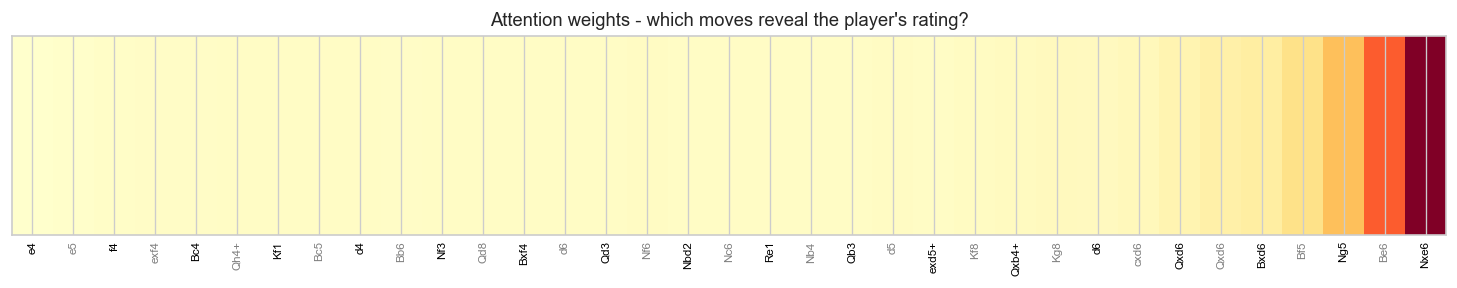

In [42]:
# find a game with ~30-50 moves for clean visualisation
test_df = df.loc[idx_test].reset_index(drop=True)
candidates = test_df[test_df['n_moves'].between(30, 50)].head(20)
game_idx = candidates.index[0]  # pick first suitable game

sample = test_ds[game_idx]
with torch.no_grad():
    mv   = sample['moves'].unsqueeze(0).to(device)
    cl   = sample['clocks'].unsqueeze(0).to(device)
    tu   = sample['turns'].unsqueeze(0).to(device)
    mask = (mv != 0).float()
    st   = sample['static'].unsqueeze(0).to(device)

    w_pred, b_pred, attn = model(mv, cl, tu, mask, st)

attn_np = attn.cpu().numpy().squeeze()
seq_len = int(mask.sum().item())
attn_np = attn_np[:seq_len]
moves_list = test_df.iloc[game_idx]['clean_moves'][:seq_len]

w_elo_true = test_df.iloc[game_idx]['WhiteElo']
b_elo_true = test_df.iloc[game_idx]['BlackElo']
print(f"Game: {seq_len} moves | "
      f"White: {w_elo_true} (pred {w_pred.item():.0f}) | "
      f"Black: {b_elo_true} (pred {b_pred.item():.0f})")

fig, ax = plt.subplots(figsize=(max(12, seq_len * 0.35), 2.5))
ax.imshow(attn_np.reshape(1, -1), aspect='auto', cmap='YlOrRd')
ax.set_yticks([])
ax.set_xticks(range(seq_len))
# color labels by side: white=black text, black=gray text
label_colors = ['black' if i % 2 == 0 else 'gray' for i in range(seq_len)]
ax.set_xticklabels(moves_list, rotation=90, fontsize=7)
for tick_label, color in zip(ax.get_xticklabels(), label_colors):
    tick_label.set_color(color)
ax.set_title('Attention weights - which moves reveal the player\'s rating?', fontsize=11)
plt.tight_layout()
plt.show()

In [53]:
from captum.attr import IntegratedGradients

model.eval()
batch = next(iter(test_loader))
mv = batch["moves"].to(device)
cl = batch["clocks"].to(device)
tu = batch["turns"].to(device)
mask = (mv != 0).float()
st = batch["static"].to(device)

def forward_static(st_in, mv_in, cl_in, tu_in, mask_in):
    # Captum expands st_in to batch_size * n_steps. Match mv/cl/tu/mask.
    if st_in.size(0) != mv_in.size(0):
        factor = st_in.size(0) // mv_in.size(0)
        mv_in = mv_in.repeat_interleave(factor, dim=0)
        cl_in = cl_in.repeat_interleave(factor, dim=0)
        tu_in = tu_in.repeat_interleave(factor, dim=0)
        mask_in = mask_in.repeat_interleave(factor, dim=0)

    w, b, _ = model(mv_in, cl_in, tu_in, mask_in, st_in)
    return (w + b) / 2

ig = IntegratedGradients(forward_static)
attr = ig.attribute(
    st,
    baselines=torch.zeros_like(st),
    additional_forward_args=(mv, cl, tu, mask),
    n_steps=32  # lower if you want it faster
)

imp = attr.abs().mean(0).cpu().numpy()
top = sorted(zip(static_cols, imp), key=lambda x: x[1], reverse=True)[:15]
for i, (name, val) in enumerate(top, 1):
    print(f"{i:02d}. {name}: {val:.4f}")

c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


01. legal_moves_white_move5: 375.4228
02. legal_moves_black_move5: 335.6926
03. total_ply_count: 268.9345
04. consec_same_piece_white: 55.2755
05. first_capture_move_white: 42.2488
06. consec_same_piece_black: 37.4790
07. white_territory_depth: 35.4926
08. first_capture_move_black: 35.1564
09. castle_move_black: 31.0542
10. castle_move_white: 26.6353
11. checks_given_white: 25.4457
12. checks_given_black: 16.3564
13. b_time_pressure: 15.5629
14. piece_captures_total: 15.3339
15. w_time_pressure: 15.0881


In [ ]:

from captum.attr import LayerIntegratedGradients
# ...existing code...
def forward_moves(mv_in):
    # Captum expands mv_in to batch_size * n_steps. Match cl/tu/mask/st.
    if mv_in.size(0) != cl.size(0):
        factor = mv_in.size(0) // cl.size(0)
        cl_in = cl.repeat_interleave(factor, dim=0)
        tu_in = tu.repeat_interleave(factor, dim=0)
        mask_in = mask.repeat_interleave(factor, dim=0)
        st_in = st.repeat_interleave(factor, dim=0)
    else:
        cl_in, tu_in, mask_in, st_in = cl, tu, mask, st

    w, b, _ = model(mv_in, cl_in, tu_in, mask_in, st_in)
    return (w + b) / 2

# shrink batch/sequence for LIG to avoid OOM
mv = mv[:1, :60]
cl = cl[:1, :60]
tu = tu[:1, :60]
mask = mask[:1, :60]
st = st[:1]

lig = LayerIntegratedGradients(forward_moves, model.move_embed)
attr_moves = lig.attribute(
    mv,
    baselines=torch.zeros_like(mv),
    n_steps=8,
    internal_batch_size=4,
)

# attr_moves shape: (1, seq_len, embed_dim) -> reduce to per-token
token_importance = attr_moves.abs().sum(dim=-1).squeeze(0).cpu().numpy()
top_moves = sorted(zip(moves_list, token_importance), key=lambda x: x[1], reverse=True)[:15]
print("\nTop moves by importance:")
for i, (move, val) in enumerate(top_moves, 1):
    print(f"{i:02d}. {move}: {val:.4f}")


Top moves by importance:
01. h4: 0.5319
02. a4: 0.3380
03. Na3: 0.0998
04. Nh3: 0.0475
05. h5: 0.0238
06. a5: 0.0063
07. g4: 0.0031
08. f3: 0.0029


In [58]:
from captum.attr import FeatureAblation

def forward_avg(mv_in, cl_in, tu_in, st_in):
    mask_in = (mv_in != 0).float()
    w, b, _ = model(mv_in, cl_in, tu_in, mask_in, st_in)
    return (w + b) / 2

fa = FeatureAblation(forward_avg)
inputs = (mv, cl, tu, st)
baselines = (torch.zeros_like(mv), torch.zeros_like(cl), torch.zeros_like(tu), torch.zeros_like(st))
attr = fa.attribute(inputs, baselines=baselines)

imp_moves = attr[0].abs().mean().item()
imp_clks  = attr[1].abs().mean().item()
imp_turns = attr[2].abs().mean().item()
imp_static= attr[3].abs().mean().item()
imp_moves, imp_clks, imp_turns, imp_static

(0.5514770746231079,
 0.0023986815940588713,
 0.005352783016860485,
 34.139522552490234)

In [ ]:
# mask out padding
mask = (mv != 0).float()

# per-sample totals (absolute)
tot_moves = (attr[0].abs() * mask).sum(dim=1)
tot_clks  = (attr[1].abs() * mask).sum(dim=1)
tot_turns = (attr[2].abs() * mask).sum(dim=1)
tot_static=  attr[3].abs().sum(dim=1)

# average totals
imp_moves  = tot_moves.mean().item()
imp_clks   = tot_clks.mean().item()
imp_turns  = tot_turns.mean().item()
imp_static = tot_static.mean().item()

# percent contribution per group
group = torch.stack([tot_moves, tot_clks, tot_turns, tot_static], dim=1)
pct = (group / group.sum(dim=1, keepdim=True)).mean(0)
print(f"Feature group importance (percent of total):\n"
        f"  Moves: {pct[0]*100:.1f}%\n"
        f"  Clocks: {pct[1]*100:.1f}%\n"
        f"  Turns: {pct[2]*100:.1f}%\n"
        f"  Static: {pct[3]*100:.1f}%")



Feature group importance (percent of total):
  Moves: 2.2%
  Clocks: 0.0%
  Turns: 0.0%
  Static: 97.8%


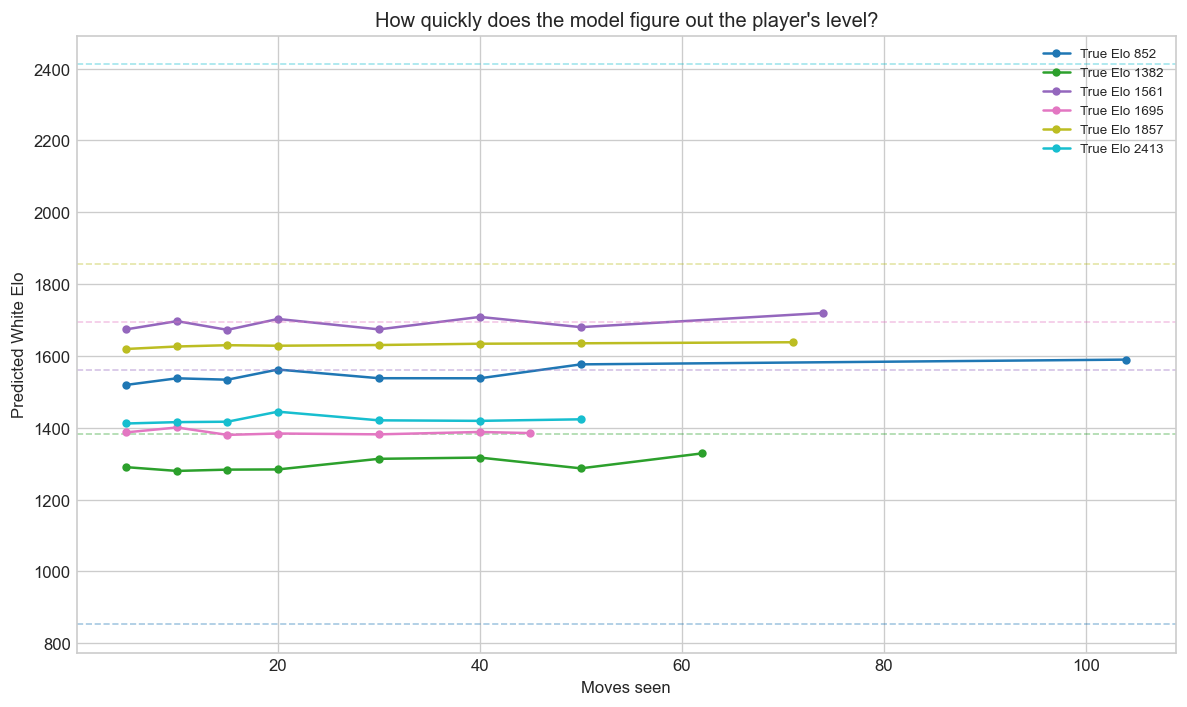

In [43]:
# How quickly does the model figure out the player's level?

# pick games spread across Elo ranges
test_df_sorted = test_df.sort_values('WhiteElo')
pick_idx = np.linspace(0, len(test_df_sorted) - 1, 6, dtype=int)
sample_games = test_df_sorted.iloc[pick_idx]

cutpoints = [5, 10, 15, 20, 30, 40, 50]
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(sample_games)))

for (_, game_row), color in zip(sample_games.iterrows(), colors):
    # find this game in the test dataset
    game_i = test_df.index.get_loc(game_row.name) if game_row.name in test_df.index else None
    if game_i is None:
        continue
    sample = test_ds[game_i]
    full_len = int((sample['moves'] != 0).sum().item())
    cuts = [c for c in cutpoints if c < full_len] + [full_len]
    true_w = game_row['WhiteElo']
    preds = []

    for cut in cuts:
        with torch.no_grad():
            mv_t   = sample['moves'][:cut].unsqueeze(0).to(device)
            cl_t   = sample['clocks'][:cut].unsqueeze(0).to(device)
            tu_t   = sample['turns'][:cut].unsqueeze(0).to(device)
            mask_t = (mv_t != 0).float()
            st_t   = sample['static'].unsqueeze(0).to(device)
            wp, _, _ = model(mv_t, cl_t, tu_t, mask_t, st_t)
            preds.append(wp.item())

    ax.plot(cuts, preds, 'o-', color=color, markersize=4,
            label=f'True Elo {true_w}')
    ax.axhline(true_w, color=color, ls='--', alpha=0.4, lw=1)

ax.set_xlabel('Moves seen')
ax.set_ylabel('Predicted White Elo')
ax.set_title('How quickly does the model figure out the player\'s level?')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

Extracting game vectors for t-SNE...
Running t-SNE on 659 game vectors...


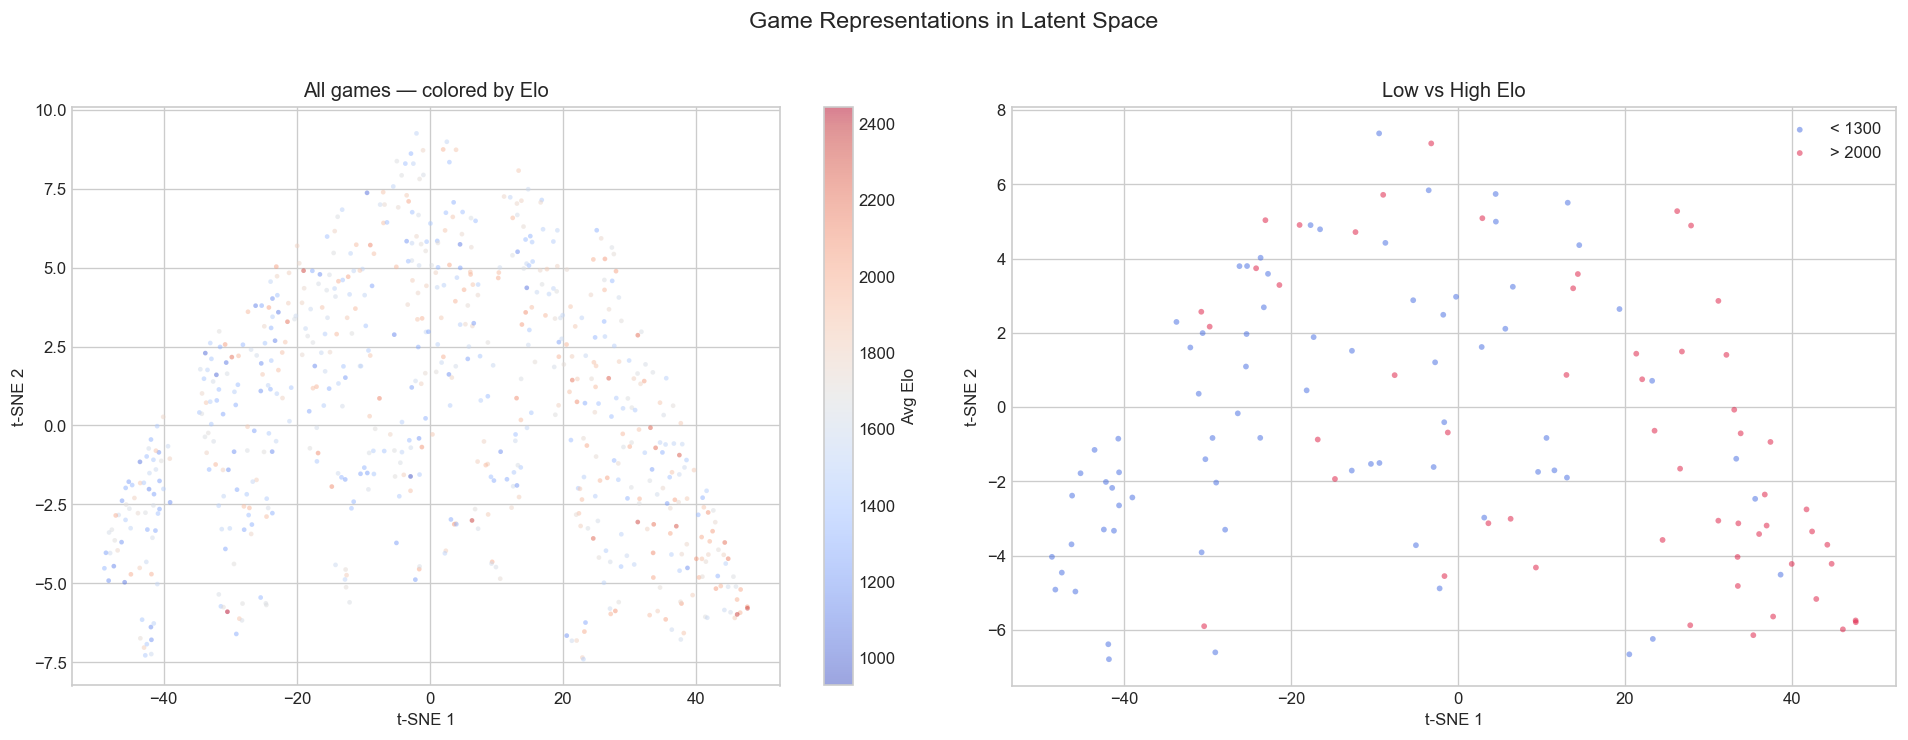

In [44]:
print("Extracting game vectors for t-SNE...")
N_TSNE = min(3000, len(test_ds))
vectors = []
elo_avg = []
model.eval()

with torch.no_grad():
    # process in batches
    tsne_loader = DataLoader(
        torch.utils.data.Subset(test_ds, range(N_TSNE)),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    for batch in tsne_loader:
        mv   = batch['moves'].to(device)
        cl   = batch['clocks'].to(device)
        tu   = batch['turns'].to(device)
        mask = batch['mask'].to(device)
        st   = batch['static'].to(device)
        tgt  = batch['targets']

        vecs = model.get_game_vector(mv, cl, tu, mask, st)
        vectors.append(vecs.cpu().numpy())
        avg_elo = ((tgt[:, 0] + tgt[:, 1]) / 2).numpy()
        elo_avg.extend(avg_elo)

vectors = np.vstack(vectors)
elo_avg = np.array(elo_avg[:len(vectors)])

print(f"Running t-SNE on {len(vectors)} game vectors...")
tsne = TSNE(n_components=2, perplexity=40, random_state=RANDOM_STATE, max_iter=1000)
emb_2d = tsne.fit_transform(vectors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# all games, colored by Elo
sc = ax1.scatter(emb_2d[:, 0], emb_2d[:, 1], c=elo_avg, cmap='coolwarm',
                 s=8, alpha=0.5, edgecolors='none')
plt.colorbar(sc, ax=ax1, label='Avg Elo')
ax1.set_title('All games — colored by Elo')
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')

# extremes only
low_mask = elo_avg < 1300
high_mask = elo_avg > 2000
ax2.scatter(emb_2d[low_mask, 0], emb_2d[low_mask, 1],
            c='royalblue', s=12, alpha=0.5, label='< 1300', edgecolors='none')
ax2.scatter(emb_2d[high_mask, 0], emb_2d[high_mask, 1],
            c='crimson', s=12, alpha=0.5, label='> 2000', edgecolors='none')
ax2.legend()
ax2.set_title('Low vs High Elo')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

fig.suptitle('Game Representations in Latent Space', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

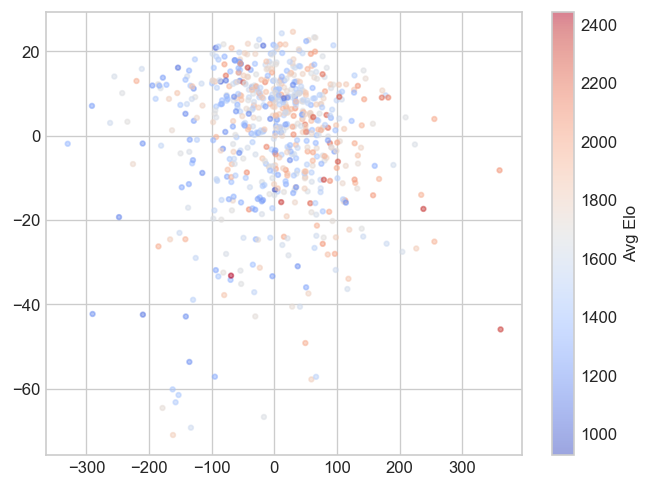

In [45]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(vectors)
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=elo_avg, cmap='coolwarm', s=8, alpha=0.5)
plt.colorbar(label="Avg Elo")

C:\Users\Elias\AppData\Local\Temp\ipykernel_27144\183951269.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(labels))


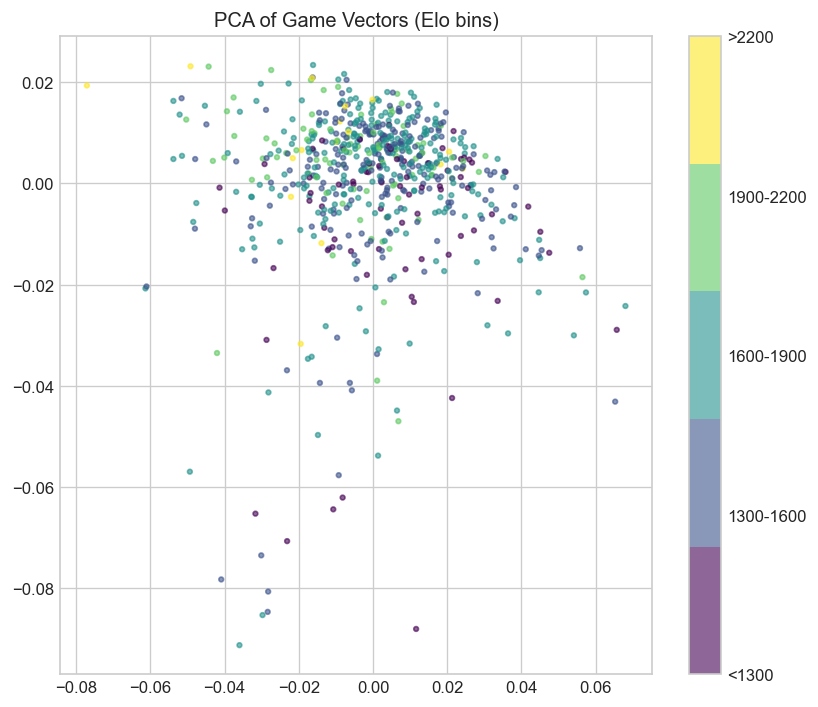

In [46]:
# L2-normalize game vectors so magnitude doesn't dominate
from sklearn.preprocessing import normalize

vectors_norm = normalize(vectors, norm="l2")
bins = [0, 1300, 1600, 1900, 2200, 4000]
labels = ["<1300", "1300-1600", "1600-1900", "1900-2200", ">2200"]
elo_bins = pd.cut(elo_avg, bins=bins, labels=labels)
bin_codes = elo_bins.codes

cmap = plt.cm.get_cmap("viridis", len(labels))
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(vectors_norm)

plt.figure(figsize=(7, 6))
plt.scatter(emb_pca[:, 0], emb_pca[:, 1], c=bin_codes, cmap=cmap, s=8, alpha=0.6)
cbar = plt.colorbar(ticks=range(len(labels)))
cbar.ax.set_yticklabels(labels)
plt.title("PCA of Game Vectors (Elo bins)")
plt.tight_layout()

c:\Masters\ALM\AppML_FinalProject\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


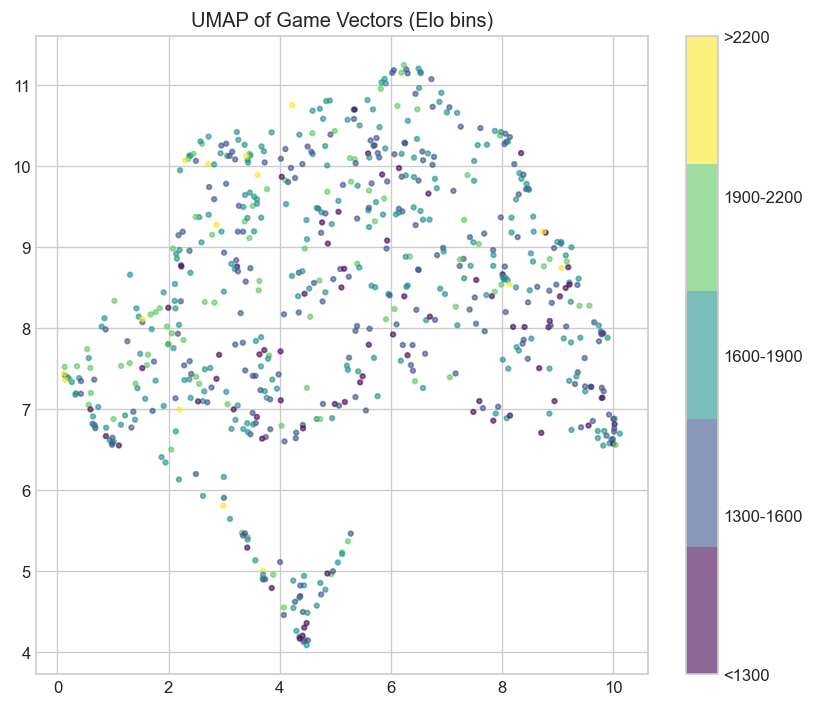

In [47]:
import umap

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=RANDOM_STATE
)
emb_umap = reducer.fit_transform(vectors_norm)

plt.figure(figsize=(7, 6))
plt.scatter(emb_umap[:, 0], emb_umap[:, 1], c=bin_codes, cmap=cmap, s=8, alpha=0.6)
cbar = plt.colorbar(ticks=range(len(labels)))
cbar.ax.set_yticklabels(labels)
plt.title("UMAP of Game Vectors (Elo bins)")
plt.tight_layout()

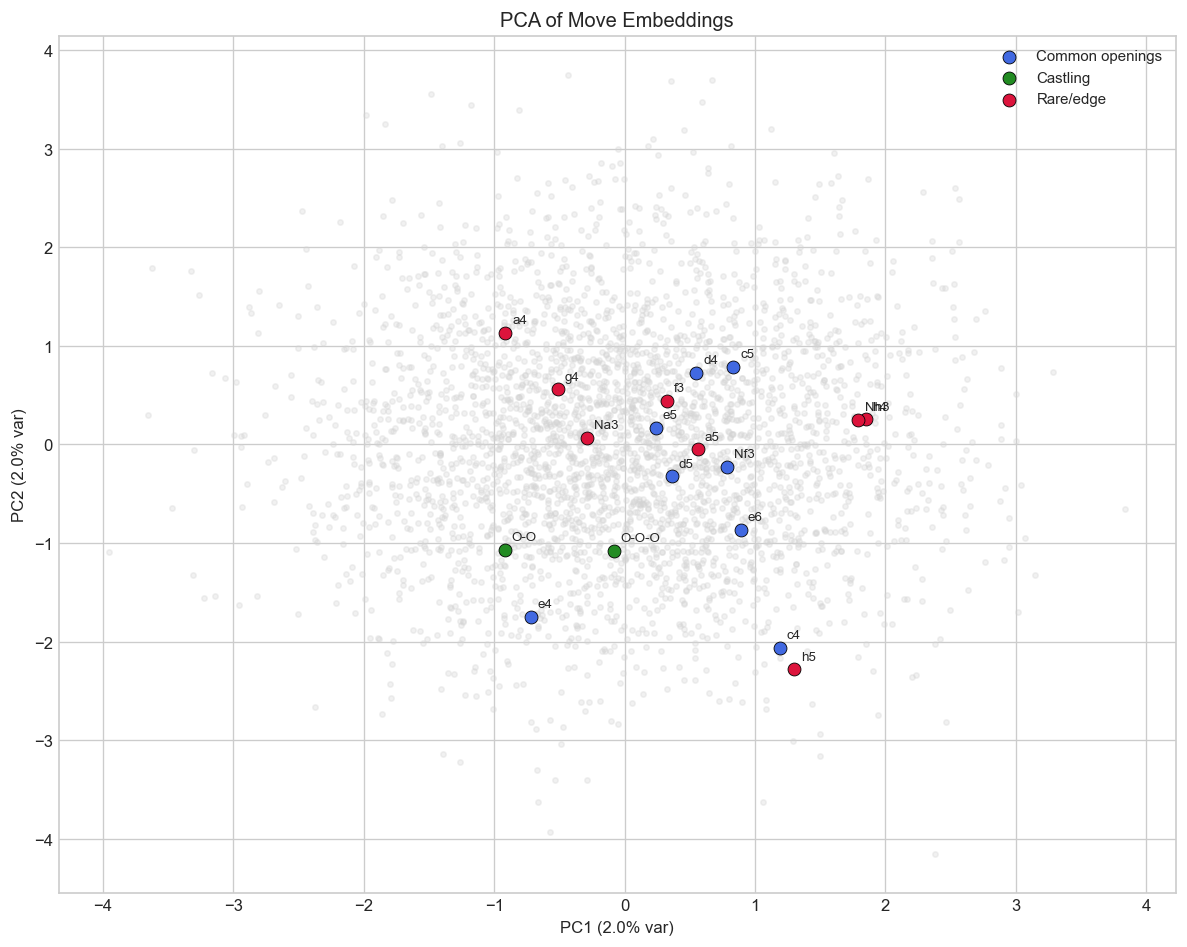

In [48]:
emb_weights = model.move_embed.weight.detach().cpu().numpy()
id_to_move = vocab.decode_map()

pca = PCA(n_components=2)
emb_pca = pca.fit_transform(emb_weights)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(emb_pca[:, 0], emb_pca[:, 1], c='lightgray', s=10, alpha=0.3)

# highlight groups
highlight_groups = {
    'Common openings': (['e4', 'd4', 'c4', 'Nf3', 'e5', 'c5', 'e6', 'd5'], 'royalblue'),
    'Castling':        (['O-O', 'O-O-O'], 'forestgreen'),
    'Rare/edge':       (['h4', 'a4', 'Na3', 'Nh3', 'h5', 'a5', 'f3', 'g4'], 'crimson'),
}

for group_name, (moves_list, color) in highlight_groups.items():
    plotted = False
    for m in moves_list:
        if m in vocab.move_to_id:
            idx = vocab.move_to_id[m]
            ax.scatter(emb_pca[idx, 0], emb_pca[idx, 1], c=color, s=60,
                       edgecolors='black', linewidth=0.5, zorder=5,
                       label=group_name if not plotted else None)
            ax.annotate(m, (emb_pca[idx, 0], emb_pca[idx, 1]),
                        fontsize=8, ha='left', va='bottom',
                        xytext=(4, 4), textcoords='offset points')
            plotted = True

ax.legend(fontsize=9)
ax.set_title('PCA of Move Embeddings')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.tight_layout()
plt.show()

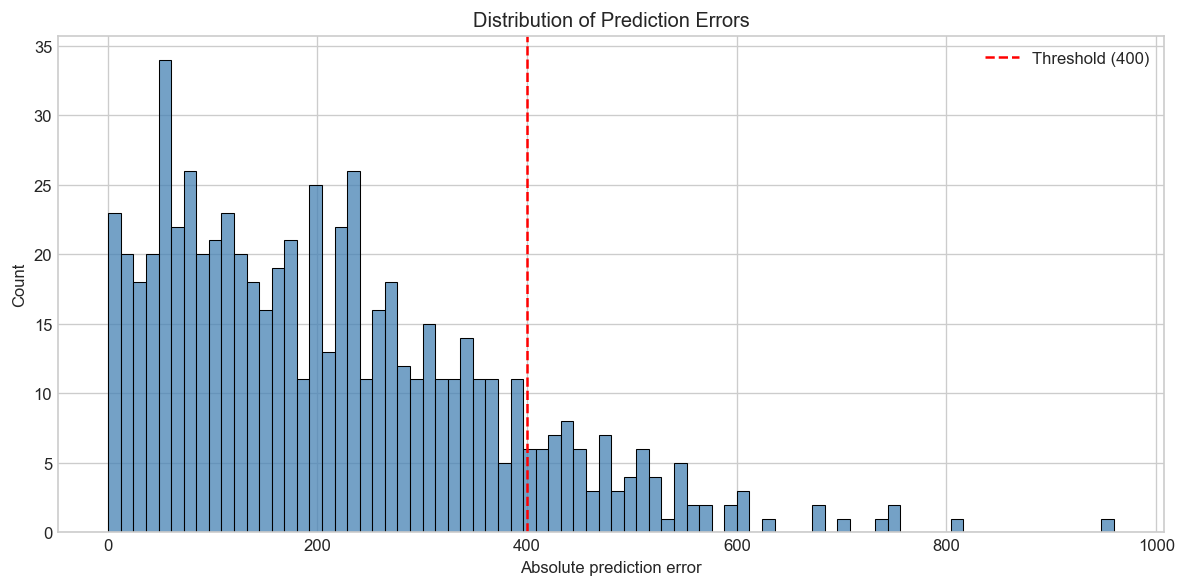


Flagged 82 games with |error| > 400 Elo (12.4%)

Top 15 OVERPERFORMERS (model thinks they play above their rating):
   Predicted      Actual      Diff
  --------------------------------
        1602         928      +675
        1789        1160      +629
        1661        1052      +608
        1631        1084      +547
        1868        1320      +547
        1580        1036      +543
        1763        1220      +542
        1656        1146      +509
        1745        1236      +509
        1818        1320      +498
        1645        1158      +487
        1659        1182      +476
        1651        1176      +475
        1622        1160      +461
        1594        1133      +461

Top 15 UNDERPERFORMERS (model thinks they play below their rating):
   Predicted      Actual      Diff
  --------------------------------
        1484        2444      -960
        1537        2342      -805
        1240        1986      -745
        1621        2366      -745
        1

In [49]:
test_avg_pred = (test_w_pred + test_b_pred) / 2
test_avg_true = (test_w_true + test_b_true) / 2
diff = test_avg_pred - test_avg_true  # positive = model thinks they're better

THRESHOLD = 400
abs_diff = np.abs(diff)

# histogram
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(abs_diff, bins=80, ax=ax, color='steelblue')
ax.axvline(THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold ({THRESHOLD})')
ax.set_xlabel('Absolute prediction error')
ax.set_ylabel('Count')
ax.set_title('Distribution of Prediction Errors')
ax.legend()
plt.tight_layout()
plt.show()

n_flagged = np.sum(abs_diff > THRESHOLD)
print(f"\nFlagged {n_flagged} games with |error| > {THRESHOLD} Elo "
      f"({n_flagged / len(diff) * 100:.1f}%)\n")

# top overperformers (potential engine use)
order_over = np.argsort(diff)[::-1][:15]
print("Top 15 OVERPERFORMERS (model thinks they play above their rating):")
print(f"  {'Predicted':>10s}  {'Actual':>10s}  {'Diff':>8s}")
print("  " + "-" * 32)
for i in order_over:
    print(f"  {test_avg_pred[i]:10.0f}  {test_avg_true[i]:10.0f}  {diff[i]:+8.0f}")

# top underperformers
order_under = np.argsort(diff)[:15]
print("\nTop 15 UNDERPERFORMERS (model thinks they play below their rating):")
print(f"  {'Predicted':>10s}  {'Actual':>10s}  {'Diff':>8s}")
print("  " + "-" * 32)
for i in order_under:
    print(f"  {test_avg_pred[i]:10.0f}  {test_avg_true[i]:10.0f}  {diff[i]:+8.0f}")

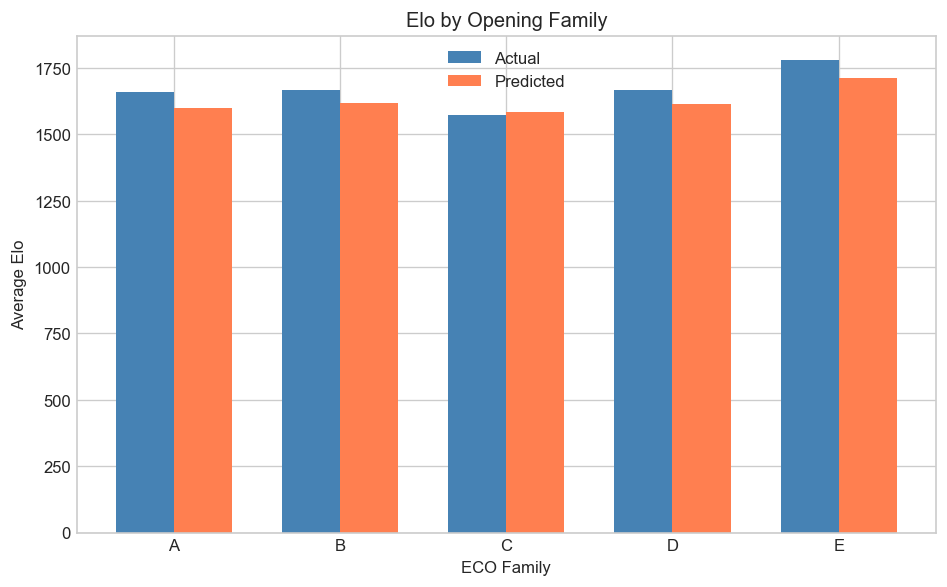


Top 5 ECO codes by average Elo (min 10 games):
    B21  avg Elo: 1709  (n=12)
    A04  avg Elo: 1694  (n=10)
    B40  avg Elo: 1690  (n=10)
    B06  avg Elo: 1661  (n=14)
    B07  avg Elo: 1659  (n=14)

Bottom 5 ECO codes by average Elo (min 10 games):
    C20  avg Elo: 1376  (n=21)
    C42  avg Elo: 1458  (n=10)
    C40  avg Elo: 1469  (n=14)
    C41  avg Elo: 1539  (n=30)
    C50  avg Elo: 1549  (n=10)


In [50]:
if 'ECO' in test_df.columns:
    eco_df = pd.DataFrame({
        'ECO': test_df['ECO'].values[:len(test_avg_true)],
        'avg_true': test_avg_true,
        'avg_pred': test_avg_pred,
    })
    eco_df['eco_family'] = eco_df['ECO'].str[0]

    # per family
    family_stats = eco_df.groupby('eco_family').agg(
        actual=('avg_true', 'mean'),
        predicted=('avg_pred', 'mean'),
        count=('avg_true', 'count')
    ).sort_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(family_stats))
    w = 0.35
    ax.bar(x - w/2, family_stats['actual'],   w, label='Actual',    color='steelblue')
    ax.bar(x + w/2, family_stats['predicted'], w, label='Predicted', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(family_stats.index)
    ax.set_xlabel('ECO Family')
    ax.set_ylabel('Average Elo')
    ax.set_title('Elo by Opening Family')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # top/bottom specific ECO codes
    eco_means = eco_df.groupby('ECO').agg(
        actual=('avg_true', 'mean'),
        count=('avg_true', 'count')
    )
    eco_means = eco_means[eco_means['count'] >= 10]  # need at least 10 games

    if len(eco_means) > 5:
        print("\nTop 5 ECO codes by average Elo (min 10 games):")
        for eco, row in eco_means.nlargest(5, 'actual').iterrows():
            print(f"  {eco:>5s}  avg Elo: {row['actual']:.0f}  (n={int(row['count'])})")

        print("\nBottom 5 ECO codes by average Elo (min 10 games):")
        for eco, row in eco_means.nsmallest(5, 'actual').iterrows():
            print(f"  {eco:>5s}  avg Elo: {row['actual']:.0f}  (n={int(row['count'])})")
else:
    print("ECO column not available, skipping opening analysis.")

---
**Done.** Summary of what this notebook covers:

1. Data loading and filtering from compressed Lichess PGN
2. Board feature extraction (captures, castling, checks, material, etc.)
3. Clock feature extraction (time management patterns)
4. Move tokenization and vocabulary building
5. BiLSTM + Attention model with multi-task Elo prediction (White + Black)
6. Training with Huber loss, gradient clipping, early stopping
7. Evaluation: MAE, per-bracket analysis, prediction quality plots
8. Attention heatmaps: which moves matter most for rating prediction
9. Progressive estimation: how quickly does the model lock onto a rating
10. Latent space clustering: t-SNE of learned game representations
11. Move embedding analysis: PCA of what the model learned about moves
12. Anomaly detection: flagging suspicious over/underperformance
13. Opening analysis: Elo patterns across ECO families